In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

In [2]:
import torchvision.models as models
print(torch.cuda.is_available())
# Loads model from .pth file
os.chdir('/user/HS401/ob00564/Documents/COM3001/KDEF/Transfer Learning')

emotionTotal = 7

# Loads MobileNetV2 trained model
mobilenet = models.mobilenet_v2(weights = 'DEFAULT')
mobilenet.classifier = torch.nn.Linear(in_features=1280, out_features= emotionTotal)
mobilenet.load_state_dict(torch.load('KDEF MobileNetV2 copy.pth'))
mobilenet.to('cuda')
mobilenet.eval()

# Loads ResNet18 trained model
resnet18 = models.resnet18(weights = None)
resnet18.fc = nn.Sequential(nn.Linear(resnet18.fc.in_features,emotionTotal))
resnet18.load_state_dict(torch.load('KDEF ResNet18 copy.pth'))
resnet18.to('cuda')
resnet18.eval()

# Loads ResNet34 trained model
resnet34 = models.resnet34(weights = None)
resnet34.fc = nn.Sequential(nn.Linear(resnet34.fc.in_features,emotionTotal))
resnet34.load_state_dict(torch.load('KDEF ResNet34 copy.pth'))
resnet34.to('cuda')
resnet34.eval()

True


/tmp/ipykernel_1602652/4148789528.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mobilenet.load_state_dict(torch.load('KDEF MobileNetV2 copy.pth'))
/tmp/ipykernel_1602

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [3]:
def confusionMatrixPlot(y_true, y_pred, title):
    # Resource used to create confusion matrix:
    # https://seaborn.pydata.org/generated/seaborn.heatmap.html
    class_names = ['Anger','Disgust','Fear','Happiness','Sadness','Surprise','Neurtal']
    conf = confusion_matrix(y_true, y_pred)
    cm = sns.heatmap(conf, annot=True, fmt=".0f")
    cm.set_xticklabels(class_names, fontsize=12, rotation=45)
    cm.set_yticklabels(class_names, fontsize=12, rotation=45)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix " + title )
    plt.show()

    # Resource to generate classification report
    # https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.classification_report.html
    class_report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(class_report)

In [4]:
from sklearn.metrics import f1_score
os.chdir('/user/HS401/ob00564/Documents/COM3001/KDEF')

print(os.getcwd())
kdef_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
kdef_loader = DataLoader(kdef_dataset, batch_size = 32, shuffle = False)

device = 'cuda'
criterion = nn.CrossEntropyLoss()

/user/HS401/ob00564/Documents/COM3001/KDEF


KDEF SPLIT MobileNetV2
Test Loss: 1.6147, Test Accuracy: 48.30%


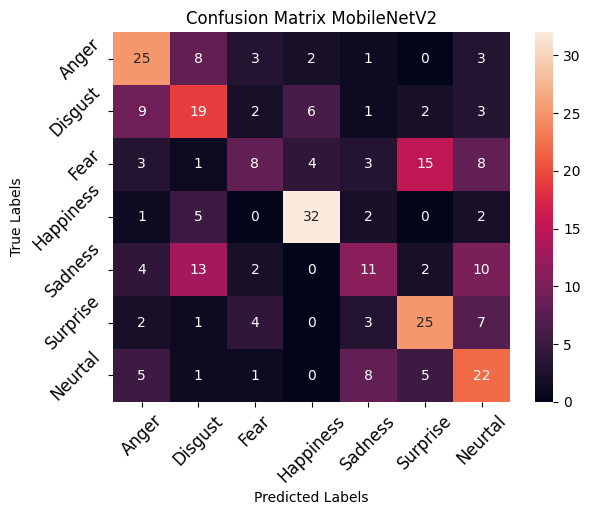

              precision    recall  f1-score   support

       Anger     0.5102    0.5952    0.5495        42
     Disgust     0.3958    0.4524    0.4222        42
        Fear     0.4000    0.1905    0.2581        42
   Happiness     0.7273    0.7619    0.7442        42
     Sadness     0.3793    0.2619    0.3099        42
    Surprise     0.5102    0.5952    0.5495        42
     Neurtal     0.4000    0.5238    0.4536        42

    accuracy                         0.4830       294
   macro avg     0.4747    0.4830    0.4695       294
weighted avg     0.4747    0.4830    0.4695       294



In [5]:
criterion = nn.CrossEntropyLoss()
print('KDEF SPLIT MobileNetV2')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(mobilenet, device, criterion, kdef_loader, 'Test')
confusionMatrixPlot(KDEF_y_true, KDEF_y_pred, 'MobileNetV2')

KDEF SPLIT ResNet18
Test Loss: 1.4090, Test Accuracy: 53.74%


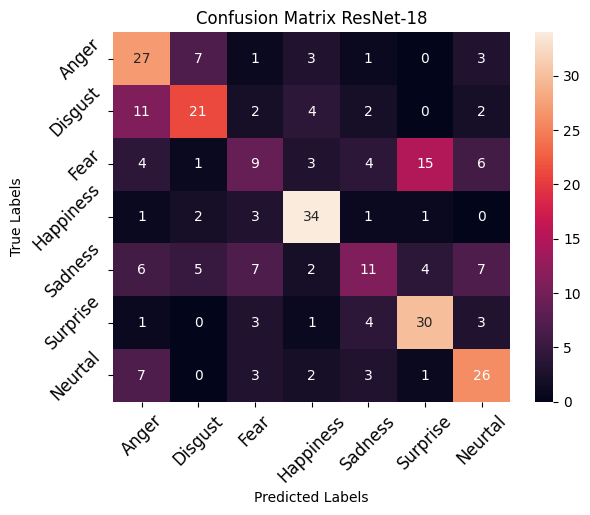

              precision    recall  f1-score   support

       Anger     0.4737    0.6429    0.5455        42
     Disgust     0.5833    0.5000    0.5385        42
        Fear     0.3214    0.2143    0.2571        42
   Happiness     0.6939    0.8095    0.7473        42
     Sadness     0.4231    0.2619    0.3235        42
    Surprise     0.5882    0.7143    0.6452        42
     Neurtal     0.5532    0.6190    0.5843        42

    accuracy                         0.5374       294
   macro avg     0.5195    0.5374    0.5202       294
weighted avg     0.5195    0.5374    0.5202       294



In [6]:
criterion = nn.CrossEntropyLoss()
print('KDEF SPLIT ResNet18')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(resnet18, device, criterion, kdef_loader, 'Test')
confusionMatrixPlot(KDEF_y_true, KDEF_y_pred, 'ResNet-18')

KDEF SPLIT ResNet34
Test Loss: 1.4829, Test Accuracy: 46.26%


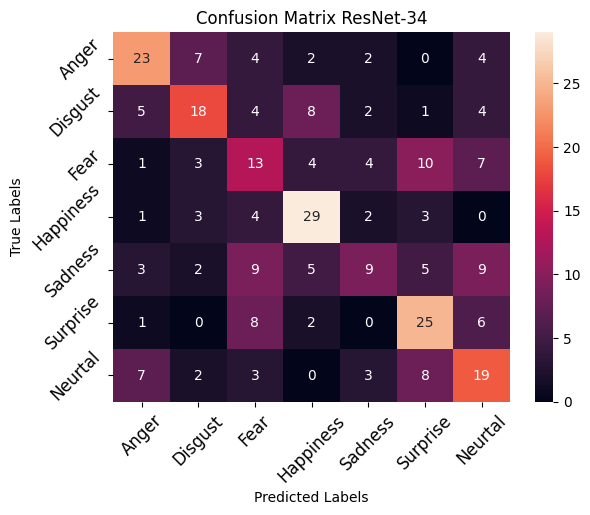

              precision    recall  f1-score   support

       Anger     0.5610    0.5476    0.5542        42
     Disgust     0.5143    0.4286    0.4675        42
        Fear     0.2889    0.3095    0.2989        42
   Happiness     0.5800    0.6905    0.6304        42
     Sadness     0.4091    0.2143    0.2812        42
    Surprise     0.4808    0.5952    0.5319        42
     Neurtal     0.3878    0.4524    0.4176        42

    accuracy                         0.4626       294
   macro avg     0.4603    0.4626    0.4545       294
weighted avg     0.4603    0.4626    0.4545       294



In [7]:
criterion = nn.CrossEntropyLoss()
print('KDEF SPLIT ResNet34')
KDEF_y_true, KDEF_y_pred, KDEF_y_score = test(resnet34, device, criterion, kdef_loader, 'Test')
confusionMatrixPlot(KDEF_y_true, KDEF_y_pred, 'ResNet-34')

In [8]:
os.chdir('/user/HS401/ob00564/Documents/COM3001/JAFFE')
print(os.getcwd())
jaffe_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
jaffe_loader = DataLoader(jaffe_dataset, batch_size = 32, shuffle = False)

os.chdir('/user/HS401/ob00564/Documents/COM3001/CK+')
print(os.getcwd())
ck_dataset = myDataset(directory = "DATASET/test", transform = test_transform)
ck_loader = DataLoader(ck_dataset, batch_size = 32, shuffle = False)

print(len(jaffe_dataset))
print(len(kdef_dataset))
print(len(ck_dataset))

device = 'cuda'
criterion = nn.CrossEntropyLoss()

/user/HS401/ob00564/Documents/COM3001/JAFFE
/user/HS401/ob00564/Documents/COM3001/CK+
21
294
93


In [10]:
os.chdir('/user/HS401/ob00564/Documents/COM3001/CK+')

print('CK+ SPLIT MobileNetV2')
ck_y_true, ck_y_pred, ck_y_score = test(mobilenet, device, criterion, ck_loader, 'Test')

print('CK+ SPLIT ResNet18')
ck_y_true, ck_y_pred, ck_y_score = test(resnet18, device, criterion, ck_loader, 'Test')

print('CK+ SPLIT ResNet34')
ck_y_true, ck_y_pred, ck_y_score = test(resnet34, device, criterion, ck_loader, 'Test')


CK+ SPLIT MobileNetV2
Test Loss: 2.0636, Test Accuracy: 10.75%
CK+ SPLIT ResNet18
Test Loss: 2.2695, Test Accuracy: 13.98%
CK+ SPLIT ResNet34
Test Loss: 2.1520, Test Accuracy: 13.98%


In [9]:
# Testing KDEF Generalizability on JAFFE using MobileNetV2
os.chdir('/user/HS401/ob00564/Documents/COM3001/JAFFE')

print('JAFFE SPLIT on MobileNetV2')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(mobilenet, device, criterion, jaffe_loader, 'Test')

print('JAFFE SPLIT on ResNet18')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(resnet18, device, criterion, jaffe_loader, 'Test')

print('JAFFE SPLIT on ResNet34')
JAFFE_y_true, JAFFE_y_pred, JAFFE_y_score = test(resnet34, device, criterion, jaffe_loader, 'Test')

JAFFE SPLIT on MobileNetV2
Test Loss: 1.8369, Test Accuracy: 33.33%
JAFFE SPLIT on ResNet18
Test Loss: 1.8091, Test Accuracy: 14.29%
JAFFE SPLIT on ResNet34
Test Loss: 1.8495, Test Accuracy: 14.29%
